In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("netflix_titles.csv")

print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [2]:
print(df.info())
print("\nMissing values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

Missing values:

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          

In [3]:
print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [4]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")
df["duration"] = df["duration"].fillna("Unknown")
df["date_added"] = df["date_added"].fillna("Not Available")

print("Missing values handled")
print(df.isnull().sum())

Missing values handled
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


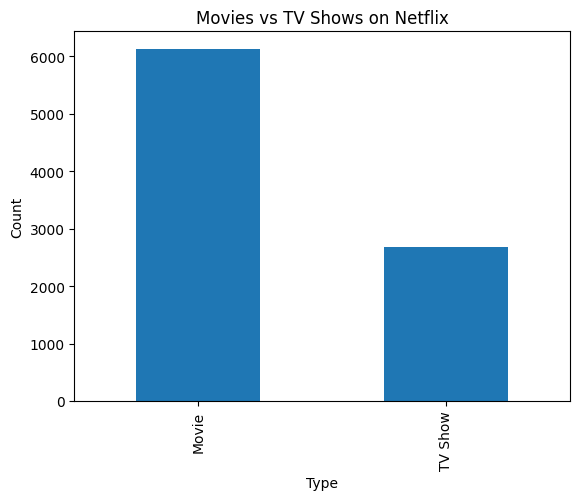

In [5]:
df["type"].value_counts().plot(kind="bar")
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

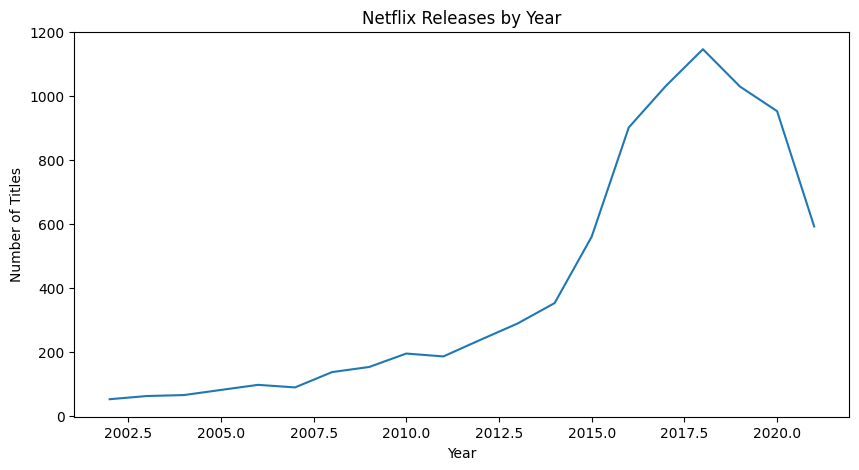

In [6]:
df["release_year"].value_counts().sort_index().tail(20).plot(figsize=(10,5))
plt.title("Netflix Releases by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

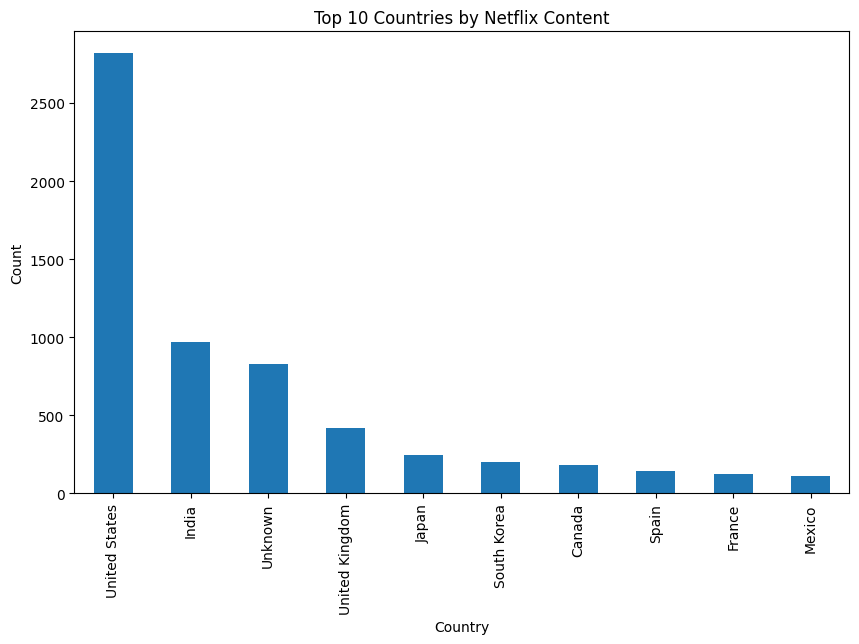

In [7]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

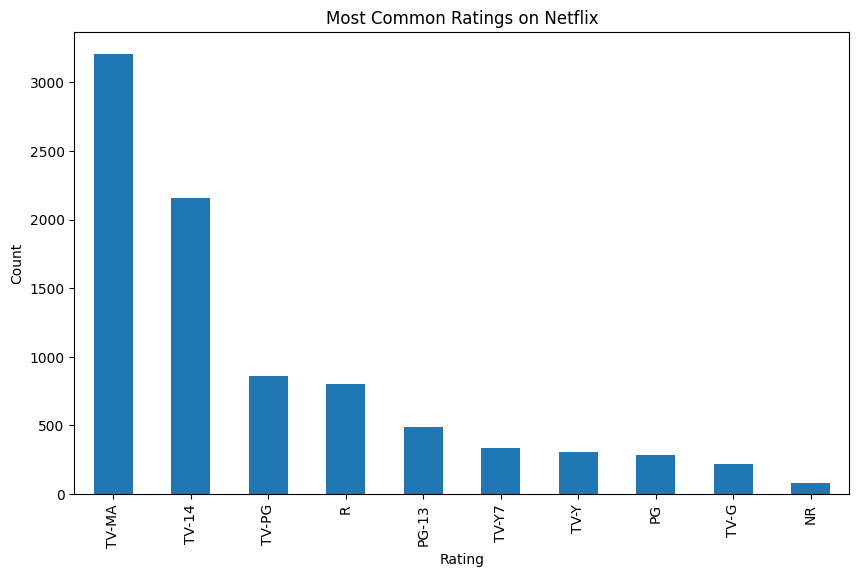

In [8]:
plt.figure(figsize=(10,6))
df["rating"].value_counts().head(10).plot(kind="bar")
plt.title("Most Common Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

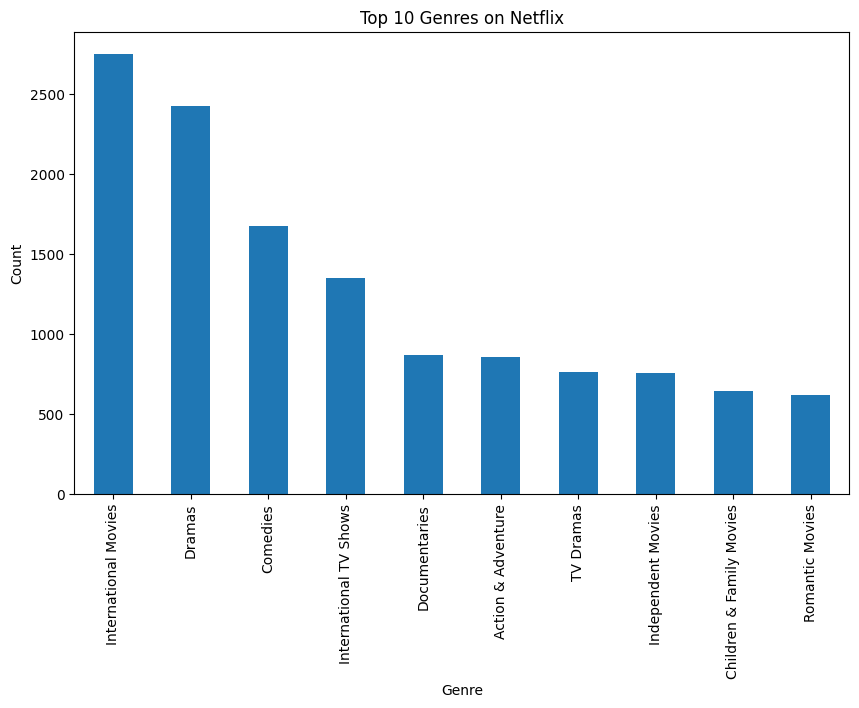

In [9]:
genres = df["listed_in"].str.split(", ").explode()

plt.figure(figsize=(10,6))
genres.value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

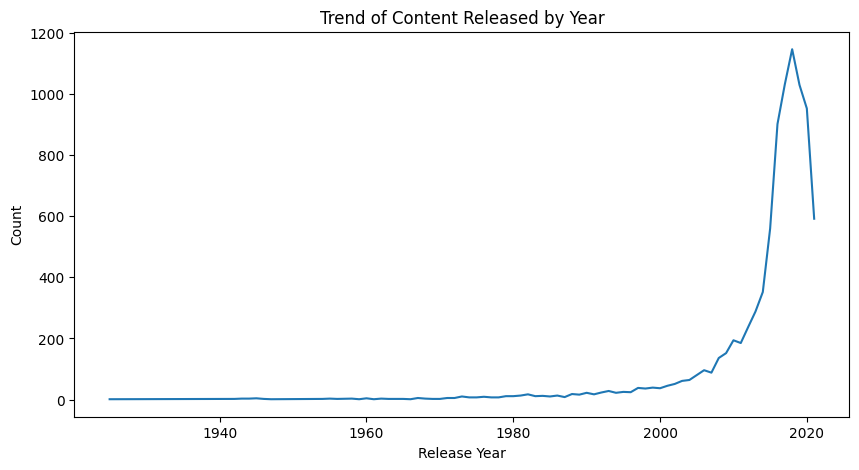

In [10]:
year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values)
plt.title("Trend of Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

# Key Findings

1. Netflix contains significantly more Movies than TV Shows.
2. Content production increased strongly in recent years.
3. The United States appears as the most common country in the dataset.
4. TV-MA and TV-14 are among the most frequent content ratings.
5. International Movies and Dramas are among the most common genres.
6. Several columns had missing values, handled during preprocessing.
7. The dataset shows global expansion of streaming content over time.